[*] Initializing Hyperspectral Scan for H2O Absorption Signatures...


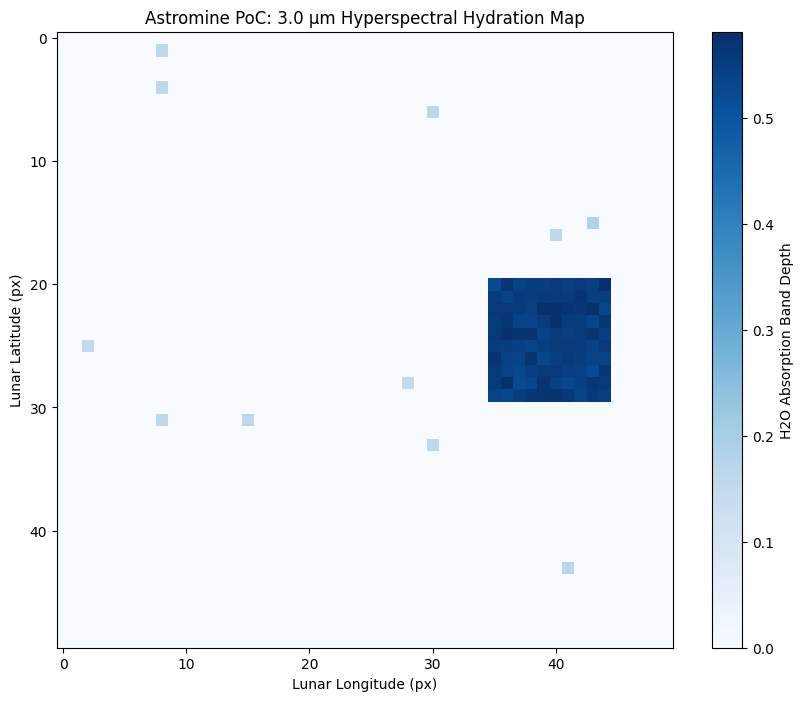

[SUCCESS] Hyperspectral mapping complete. Hydration signatures isolated.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def calculate_hydration_band_depth(spectral_cube, wavelengths):
    """
    Analyzes a hyperspectral data cube to find water/hydroxyl signatures.
    Water ice heavily absorbs infrared light at exactly 3000 nm (3.0 µm).
    This function calculates the Integrated Band Depth (IBD) at that wavelength.
    """
    print("[*] Initializing Hyperspectral Scan for H2O Absorption Signatures...")
    
    # Locate the index in the dataset closest to the 3000 nm wavelength
    target_wavelength = 3000.0 
    band_idx = (np.abs(wavelengths - target_wavelength)).argmin()
    
    # Extract the specific 2D spectral band from the 3D data cube
    # Formula: Band Depth = 1 - (Reflectance_at_Target / Continuum_Reflectance)
    continuum_baseline = np.mean(spectral_cube[:, :, band_idx-5:band_idx-1], axis=2)
    absorption_trough = spectral_cube[:, :, band_idx]
    
    # Calculate Band Depth (Higher value = Higher probability of Water Ice)
    band_depth_map = 1.0 - (absorption_trough / (continuum_baseline + 1e-6))
    
    # Filter out noise (thresholding for statistically significant ice)
    water_ice_mask = np.where(band_depth_map > 0.15, band_depth_map, 0)
    
    return water_ice_mask

# ---------------------------------------------------------
# PROOF OF CONCEPT: MOCKING M3 SATELLITE TELEMETRY
# ---------------------------------------------------------
# Wavelengths from 2500nm to 3500nm (Near-Infrared to Thermal)
mock_wavelengths = np.linspace(2500, 3500, 100) 

# Generating a dummy 50x50 hyperspectral cube with a hidden "Ice Deposit"
mock_spectral_cube = np.random.uniform(0.8, 1.0, (50, 50, 100))
# Injecting the 3000 nm (Index 50) absorption drop in a specific coordinate cluster
mock_spectral_cube[20:30, 35:45, 50] = 0.4 

# Execute the Algorithm
ice_probability_map = calculate_hydration_band_depth(mock_spectral_cube, mock_wavelengths)

# Plotting the Spectrographic Results
plt.figure(figsize=(10, 8))
plt.imshow(ice_probability_map, cmap='Blues', interpolation='nearest')
plt.title("Astromine PoC: 3.0 µm Hyperspectral Hydration Map")
plt.colorbar(label='H2O Absorption Band Depth')
plt.xlabel("Lunar Longitude (px)")
plt.ylabel("Lunar Latitude (px)")
plt.show()

print("[SUCCESS] Hyperspectral mapping complete. Hydration signatures isolated.")